In [2]:
import pandas as pd

df = pd.read_csv("lpg_full_data.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               47 non-null     object 
 1   region_type        47 non-null     object 
 2   location           47 non-null     object 
 3   domestic_price     47 non-null     float64
 4   commercial_price   47 non-null     float64
 5   change_domestic    47 non-null     int64  
 6   change_commercial  47 non-null     int64  
 7   war_flag           47 non-null     int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 3.1+ KB
None
         date region_type   location  domestic_price  commercial_price  \
0  19-03-2026        City  New Delhi           913.0            1884.5   
1  19-03-2026        City    Kolkata           939.0            1988.5   
2  19-03-2026        City     Mumbai           912.5            1836.0   
3  19-03-2026        City    Chennai           928.5   

In [3]:
print(df.describe())

       domestic_price  commercial_price  change_domestic  change_commercial  \
count       47.000000         47.000000             47.0               47.0   
mean       951.106383       2018.797872             60.0              144.0   
std         43.783178        135.754120              0.0                0.0   
min        910.500000       1836.000000             60.0              144.0   
25%        921.000000       1912.000000             60.0              144.0   
50%        937.500000       1996.500000             60.0              144.0   
75%        965.000000       2082.750000             60.0              144.0   
max       1073.500000       2364.000000             60.0              144.0   

       war_flag  
count      47.0  
mean        1.0  
std         0.0  
min         1.0  
25%         1.0  
50%         1.0  
75%         1.0  
max         1.0  


In [4]:
df.sort_values(by= "domestic_price" , ascending = False).head(5)

//top 5 most expensive prices (Domestic)

// Remote and northeastern regions show significantly higher LPG prices,indicating logistical and supply chain challenges.

,date,region_type,location,domestic_price,commercial_price,change_domestic,change_commercial,war_flag
43,19-03-2026,State,Tripura,1073.5,2345.5,60,144,1
40,19-03-2026,State,Sikkim,1065.5,2364.0,60,144,1
34,19-03-2026,State,Mizoram,1065.0,2332.0,60,144,1
32,19-03-2026,State,Manipur,1064.5,2332.5,60,144,1
12,19-03-2026,City,Patna,1002.5,2133.5,60,144,1


In [5]:
df.sort_values(by= "domestic_price" ).head(5)
//top 5 cheapest prices (Domestic)
// The lowest prices are concentrated in the western and central regions, suggesting better supply chain efficiency and lower transportation costs.
//Metro cities benefit from better distribution infrastructure, resulting in relatively lower LPG prices.

,date,region_type,location,domestic_price,commercial_price,change_domestic,change_commercial,war_flag
5,19-03-2026,City,Noida,910.5,1884.5,60,144,1
2,19-03-2026,City,Mumbai,912.5,1836.0,60,144,1
31,19-03-2026,State,Maharashtra,912.5,1836.0,60,144,1
0,19-03-2026,City,New Delhi,913.0,1884.5,60,144,1
22,19-03-2026,State,Delhi,913.0,1884.5,60,144,1


In [13]:
df.groupby("region_type")["domestic_price"].mean().sort_values(ascending=False)
//State-level averages show higher variability compared to metro cities, indicating uneven distribution across regions.

region_type
State    958.893939
City     932.750000
Name: domestic_price, dtype: float64

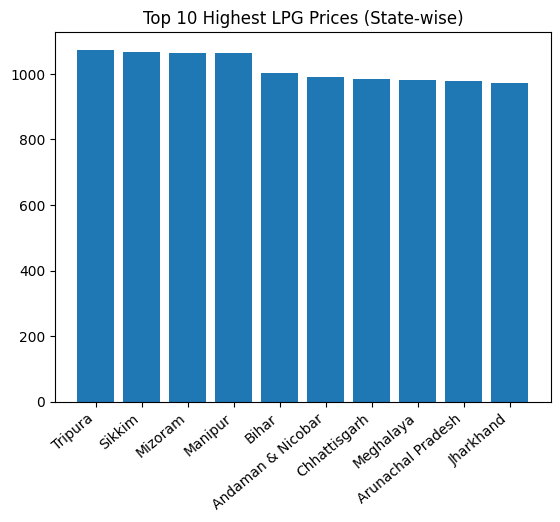

In [15]:
import matplotlib.pyplot as plt

top_states = df[df["region_type"]=="State"].sort_values(
    by="domestic_price", ascending=False).head(10)

plt.figure()
plt.bar(top_states["location"], top_states["domestic_price"])
plt.xticks(rotation=40, ha="right")
plt.title("Top 10 Highest LPG Prices (State-wise)")
plt.show()

//A uniform increase of ₹60 across all regions suggests centralized policy intervention, likely triggered by global supply disruptions.
//

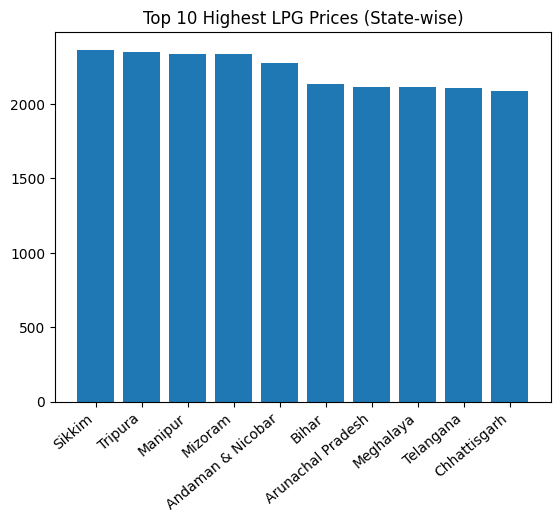

In [16]:
import matplotlib.pyplot as plt

top_states = df[df["region_type"]=="State"].sort_values(
    by="commercial_price", ascending=False).head(10)

plt.figure()
plt.bar(top_states["location"], top_states["commercial_price"])
plt.xticks(rotation=40, ha="right")
plt.title("Top 10 Highest LPG Prices (State-wise)")
plt.show()

 🔥 City vs State Comparison (IMPORTANT)

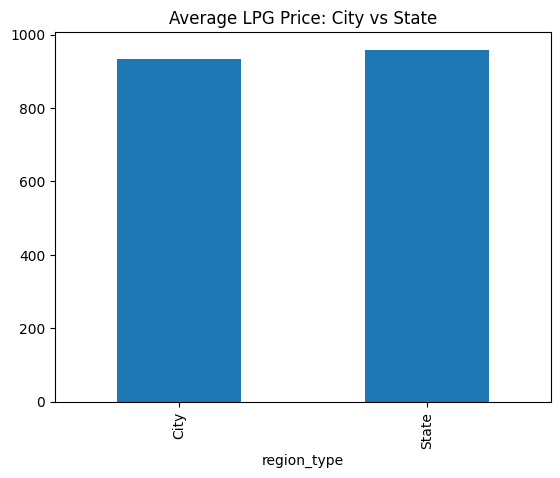

In [17]:
df.groupby("region_type")["domestic_price"].mean().plot(kind="bar")
plt.title("Average LPG Price: City vs State")
plt.show()
//State-level averages show higher variability compared to metro cities, indicating uneven distribution across regions.

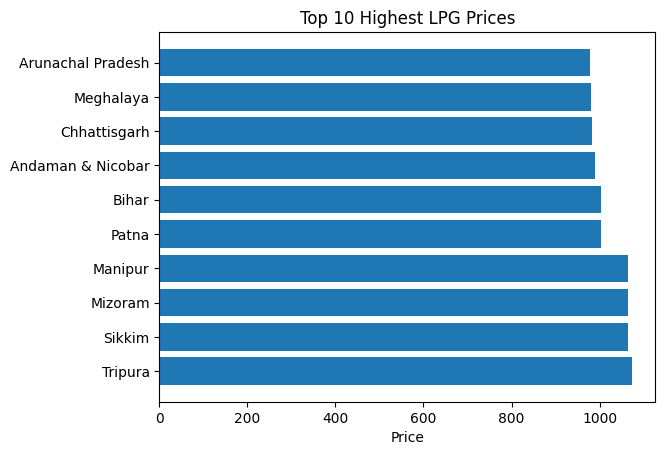

In [18]:
// 🔥 Top 10 MOST EXPENSIVE 

top = df.sort_values(by="domestic_price", ascending=False).head(10)

plt.figure()
plt.barh(top["location"], top["domestic_price"])
plt.title("Top 10 Highest LPG Prices")
plt.xlabel("Price")
plt.show()

// The horizontal bar chart highlights the stark price disparities, with northeastern states like Arunachal Pradesh and Assam at the top, underscoring the urgent need for targeted policy interventions to address regional inequalities in LPG pricing.

<Figure size 640x480 with 0 Axes>

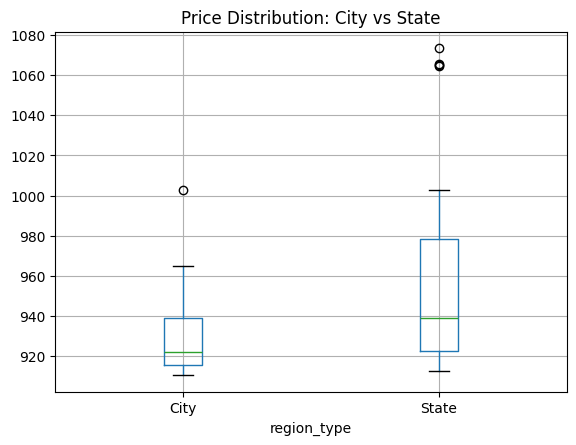

In [19]:
plt.figure()
df.boxplot(column="domestic_price", by="region_type")
plt.title("Price Distribution: City vs State")
plt.suptitle("")
plt.show()

//regionalinequalitycomparison


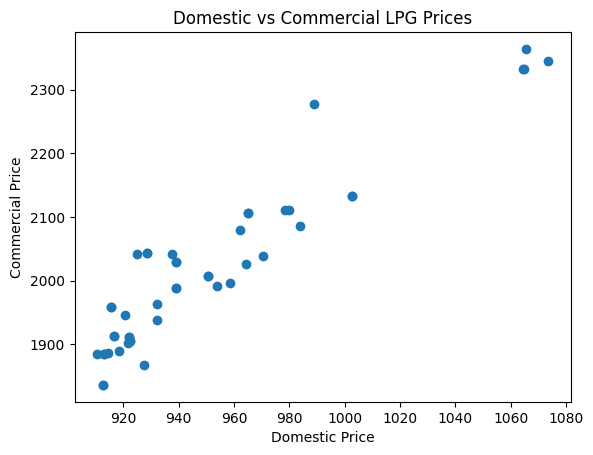

In [20]:
plt.figure()
plt.scatter(df["domestic_price"], df["commercial_price"])
plt.xlabel("Domestic Price")
plt.ylabel("Commercial Price")
plt.title("Domestic vs Commercial LPG Prices")
plt.show()

// Domestic vs Commercial Comparison
//Strong correlation → both affected by same global factors (oil/war)

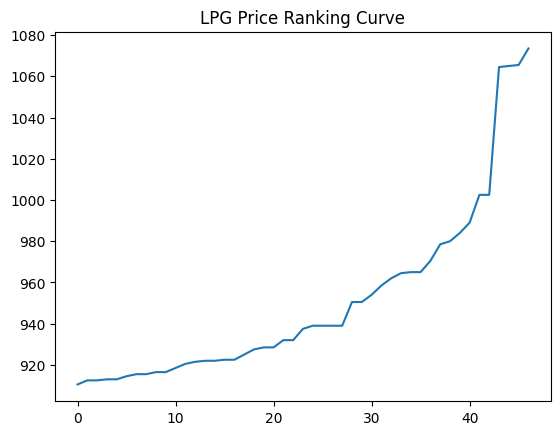

In [21]:
df_sorted = df.sort_values(by="domestic_price")

plt.figure()
plt.plot(df_sorted["domestic_price"].values)
plt.title("LPG Price Ranking Curve")
plt.show()

crude Oil data fetching from AlphaVantage Api 

In [22]:
import requests
import pandas as pd

API_KEY = "YOUR_API_KEY"

url = f"https://www.alphavantage.co/query?function=BRENT&interval=daily&apikey={OLT55Z2AG1W5QRPI}"

response = requests.get(url)
data = response.json()

# Extract data
oil_data = []

for date, value in data["data"].items():
    oil_data.append([date, float(value)])

oil_df = pd.DataFrame(oil_data, columns=["date", "oil_price"])

oil_df.to_csv("oil_prices.csv", index=False)

print(oil_df.head())

NameError: name 'OLT55Z2AG1W5QRPI' is not defined

import requests
import pandas as pd

API_KEY = "YOUR_API_KEY"

url = f"https://www.alphavantage.co/query?function=BRENT&interval=daily&apikey={OLT55Z2AG1W5QRPI}"

response = requests.get(url)
data = response.json()

# Extract data
oil_data = []

for date, value in data["data"].items():
    oil_data.append([date, float(value)])

oil_df = pd.DataFrame(oil_data, columns=["date", "oil_price"])

oil_df.to_csv("oil_prices.csv", index=False)

print(oil_df.head())

In [ ]:
# cell 20: corrected AlphaVantage oil data fetch
if API_KEY == "YOUR_API_KEY":
    raise ValueError("Please set API_KEY to a valid AlphaVantage API key before running this cell.")

url = f"https://www.alphavantage.co/query?function=BRENT&interval=daily&apikey={API_KEY}"
response = requests.get(url)
response.raise_for_status()

data = response.json()
if "data" not in data:
    raise ValueError("Unexpected response format from AlphaVantage: %s" % data)

oil_data = []
for date, value in data["data"].items():
    oil_data.append([date, float(value)])

oil_df = pd.DataFrame(oil_data, columns=["date", "oil_price"])
oil_df.to_csv("oil_prices.csv", index=False)
print(oil_df.head())